## **Importing core libraries**

In [45]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

## **Dataset loading**

In [30]:
from google.colab import auth
auth.authenticate_user()

import gspread
import pandas as pd
from google.auth import default

creds, _ = default()
gc = gspread.authorize(creds)

sheet = gc.open("running_records").sheet1

df = pd.DataFrame(sheet.get_all_records())
df = df.rename(columns = {
    "Date" : "date",
    "Distance [km]" : "distance",
    "Avg Pace [/km]" : "avg_pace",
    "Moving Time [min:sec]" : "mov_time",
    "Elevation Gain [m]" : "elev_gain ",
    "Max Elevation [m]" : "max_elev",
    "Steps" : "steps",
    "Comment" : "comment"
})

df.set_index('date', inplace = True)
df.head()

,distance,avg_pace,mov_time,elev_gain,max_elev,steps,comment
date,,,,,,,
2/6/2026 7:42:00,3.15,6:43,21:13,10,42,2976,Longest run to date
3/6/2026 17:56:00,2.36,6:14,14:42,10,22,2148,
4/6/2026 18:14:00,1.33,4:56,6:34,4,28,1018,Fastest 1K to date
4/6/2026 18:39:00,2.26,5:52,13:18,0,42,2006,2nd fastest mile


In [46]:
# Transforming min:sec data into time format

# Pace
df["avg_pace"] = pd.to_timedelta("00:" + df["avg_pace"])
df["avg_pace_min"] = df["avg_pace"].dt.total_seconds() / 60

# Moving time
mov_time_str = df["mov_time"].astype(str) # Conversion a string

# Si tiene solo un ":" → formato mm:ss → agregamos "00:"
# Si tiene dos ":" → formato hh:mm:ss → lo dejamos igual
df["mov_time"] = pd.to_timedelta(
    np.where(
        mov_time_str.str.count(":") == 1,
        "00:" + mov_time_str,
        mov_time_str
    )
)

In [47]:
df

,distance,avg_pace,mov_time,elev_gain,max_elev,steps,comment,steps/km,avg_pace_min
date,,,,,,,,,
2/6/2026 7:42:00,3.15,0 days 00:06:43,0 days 00:21:13,10,42,2976,Longest run to date,944.761905,6.716667
3/6/2026 17:56:00,2.36,0 days 00:06:14,0 days 00:14:42,10,22,2148,,910.169492,6.233333
4/6/2026 18:14:00,1.33,0 days 00:04:56,0 days 00:06:34,4,28,1018,Fastest 1K to date,765.413534,4.933333
4/6/2026 18:39:00,2.26,0 days 00:05:52,0 days 00:13:18,0,42,2006,2nd fastest mile,887.610619,5.866667


In [32]:
df['steps/km'] = df['steps'] / df['distance']

## **Plotting some metrics**

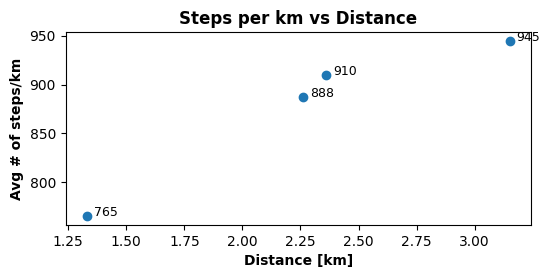

In [59]:
# On average, how many steps do I take when running different distances?

plt.figure(figsize=(6, 2.5))  # width, height
plt.scatter(df["distance"], df["steps/km"])
plt.title("Steps per km vs Distance", fontweight = "bold")
plt.ylabel("Avg # of steps/km", fontweight = "bold")
plt.xlabel('Distance [km]', fontweight = "bold")

for x, y in zip(df["distance"], df["steps/km"]):
    plt.annotate(
        f"{y:.0f}",
        xy=(x, y),
        xytext=(5,0),
        textcoords="offset points",
        fontsize=9
    )

plt.show()

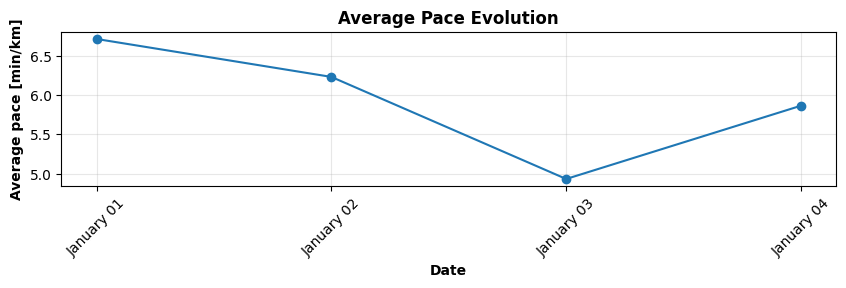

In [66]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

plt.figure(figsize=(10, 2))

plt.plot(df.index, df["avg_pace_min"], marker="o")

plt.xlabel("Date", fontweight="bold")
plt.ylabel("Average pace [min/km]", fontweight="bold")
plt.title("Average Pace Evolution", fontweight="bold")

plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%B %d"))
plt.xticks(rotation=45)

plt.grid(True, alpha=0.3)
plt.show()